Задача 1. Обнаружение фальшивых новостей
Фальшивые новости — это ложная информация, распространяемая через социальные сети и другие сетевые СМИ для достижения политических или идеологических целей.

Твоя  задача -  используя библиотеку sklearn построить модель классического машинного обучения, которая может с высокой точностью более 90% определять, является ли новость реальной (REAL） или фальшивой（FAKE).

Ты должен самостоятельно изучить и применить к задаче TfidfVectorizer для извлечения признаков из текстовых данных и PassiveAggressiveClassifier.

Ты  можешь использовать данный датасет для обучения.

Построй матрицу ошибок (confusion matrix). Представь, что ваш заказчик очень любит графики и диаграммы. Визуализируй для него результаты там, где это возможно.

Что такое TfidfVectorizer?
Изучение текстовых данных является одной из фундаментальных задач в области анализа данных и машинного обучения.

Однако тексты представляют собой сложные и многомерные структуры, которые не могут быть напрямую обработаны алгоритмами машинного обучения. В этом контексте извлечение признаков — это процесс преобразования текстовых данных в числовые векторы, которые могут быть использованы для обучения моделей и анализа. Этот шаг играет ключевую роль в предварительной обработке данных перед применением алгоритмов.

Term Frequency-Inverse Document Frequency (TF-IDF) — это один из наиболее распространенных и мощных методов для извлечения признаков из текстовых данных. TF-IDF вычисляет важность каждого слова в документе относительно количества его употреблений в данном документе и во всей коллекции текстов. Этот метод позволяет выделить ключевые слова и понять, какие слова имеют больший вес для определенного документа в контексте всей коллекции.

TfidfVectorizer преобразует коллекцию необработанных документов в матрицу объектов TF-IDF.

Что такое пассивно-агрессивный классификатор (PassiveAggressiveClassifier)?
Пассивно-агрессивный классификатор – это алгоритм онлайн-обучения, в котором вы обучаете систему постепенно, загружая ее экземпляры последовательно, отдельно или небольшими группами, называемыми мини-партиями.

При онлайн-обучении модель машинного обучения обучается и развертывается в производственной среде таким образом, чтобы обучение продолжалось по мере поступления новых наборов данных. Таким образом, мы можем сказать, что такой алгоритм, как пассивно-агрессивный классификатор, лучше всего подходит для систем, которые получают данные в непрерывном потоке. Он пассивно реагирует на правильные классификации и агрессивно реагирует на любые просчеты.

In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/practica/fake_news.csv

--2025-10-11 22:56:21--  https://storage.yandexcloud.net/academy.ai/practica/fake_news.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30696129 (29M) [text/csv]
Saving to: ‘fake_news.csv’

fake_news.csv       100%[===================>]  29.27M  15.6MB/s    in 1.9s    

2025-10-11 22:56:24 (15.6 MB/s) - ‘fake_news.csv’ saved [30696129/30696129]



In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("fake_news.csv")

df['text'] = df['title'] + " " + df['text']
df = df.drop(['title'], axis=1)

x = df['text']
y = df['label']

# test_size = 0.2 - разделяем данные на тестовые 20% и для обучения 80%
# rabdom_state - для одинакового разбиения данных
# stratify - для сохранения пропорций классов в выборках
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# stop_words - убирает лишние слова (необходимые для грамматики, но не несут смысловой нагрузки)
# max_df - игнорируем слова, встречающиеся более чем в 70% документов
# ngram_range - берем не только слово, но и словосочетания
tfidf = TfidfVectorizer(stop_words='english', max_df=0.7, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
pac = PassiveAggressiveClassifier(max_iter=1000, random_state=42)
pac.fit(X_train_tfidf, y_train)

PassiveAggressiveClassifier(random_state=42)

Accuracy: 0.94


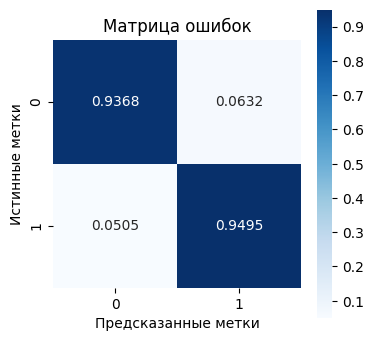

In [ ]:
y_pred = pac.predict(X_test_tfidf)
score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {score:.2f}")

plt.figure(figsize=(4,4))
confusion = confusion_matrix(y_test, y_pred)
confusion_normalized = confusion / confusion.sum(axis=1, keepdims=True)
axis_labels = range(2)
ax = sns.heatmap(
    confusion_normalized, xticklabels=axis_labels, yticklabels=axis_labels,
    cmap='Blues', annot=True, fmt='.4f', square=True)
plt.title("Матрица ошибок")
plt.ylabel("Истинные метки")
plt.xlabel("Предсказанные метки")

plt.show()


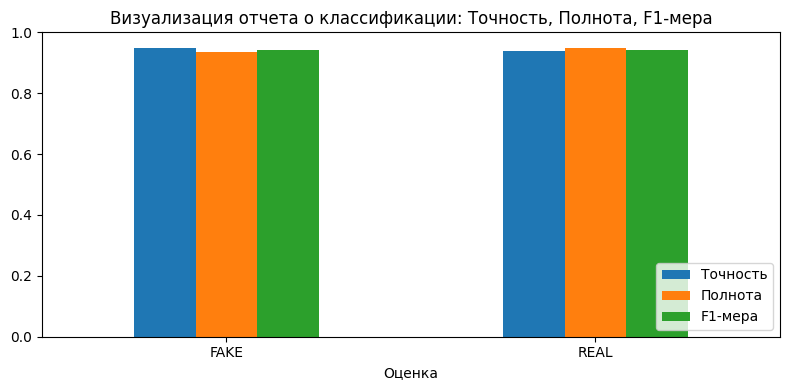

In [ ]:
df_report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

classes = ['FAKE', 'REAL']
metrics = ['precision', 'recall', 'f1-score']

df_plot = df_report.loc[classes, metrics]
df_plot.columns = ['Точность', 'Полнота', 'F1-мера']
df_plot.plot(kind='bar', figsize=(8, 4))

plt.title('Визуализация отчета о классификации: Точность, Полнота, F1-мера')
plt.xlabel('Оценка')
plt.ylim(0, 1)
plt.xticks(rotation = 0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Задача 2. Обнаружение болезни паркинсона с помощью XGBoost
Твоя задача с помощью Data Science предсказать заболевание паркинсона на ранней стадии, используя алгоритм машинного обучения XGBoost и библиотеку sklearn для нормализации признаков. Как это сделать? Тебя  придется самостоятельно изучить данный вопрос.

Используй следующий датасет UCI ML Parkinsons. Описание признаков и меток датасета представлены здесь. От тебя  требуется помимо создания самой модели получить ее точность на тестовой выборке. Выборки делить в соотношении 80% обучающая, 20% - тестовая.

Дополнительные баллы ты получишь, если сможешь получить точность более 95%.

Что такое болезнь Паркинсона?
Болезнь Паркинсона - прогрессирующее заболевание центральной нервной системы, влияющее на движение и вызывающее тремор и скованность движений.

У нее 5 стадий, и ежегодно ею страдают более 1 миллиона человек только в одной Индии. Это хроническое заболевание, и его пока не лечат. Это нейродегенеративное расстройство, поражающее нейроны головного мозга, вырабатывающие дофамин.

Что такое XGBoost?
XGBoost - это новый алгоритм машинного обучения, разработанный с учетом скорости и производительности.

XGBoost расшифровывается как экстремальное повышение градиента и основан на деревьях решений.

Многие считают его одним из лучших алгоритмов и из-за его высокой производительности при решении задач регрессии и классификации, рекомендуют его в качестве первого выбора во многих ситуациях. XGBoost прославился тем, что выиграл множество соревнований Kaggle

Есть 2 распространенных способа использования XGBoost:

Learning API: это базовый низкоуровневый способ использования XGBoost. Простой и мощный, он включает встроенный метод перекрестной проверки.
Scikit-Learn API: это интерфейс-оболочка Scikit-Learn для XGBoost. Он позволяет использовать XGBoost совместимым с scikit-learn способом, точно так же, как вы использовали бы любую нативную модель scikit-learn.
В этом задании мы рекомендуем использовать XGBClassifier из библиотеки xgboost, который является реализацией scikit-learn API для классификации XGBoost.

In [ ]:
pip install xgboost scikit-learn

In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/practica/parkinsons.data

--2025-10-12 09:57:54--  https://storage.yandexcloud.net/academy.ai/practica/parkinsons.data
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 40697 (40K) [application/x-www-form-urlencoded]
Saving to: ‘parkinsons.data’

parkinsons.data     100%[===================>]  39.74K   231KB/s    in 0.2s    

2025-10-12 09:57:55 (231 KB/s) - ‘parkinsons.data’ saved [40697/40697]



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from matplotlib import pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score

In [ ]:
df = pd.read_csv("parkinsons.data")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [ ]:
x = df.drop(['name', 'status'], axis = 1)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
param_grid = {
    'n_estimators': [ 500, 600, 700],
    'max_depth': [ 2, 3, 4],
    'learning_rate': [0.005, 0.01, 0.05, 0,1]
}

grid = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss'),
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Лучшие параметры:", grid.best_params_)

Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 600}


In [ ]:
model = XGBClassifier(
    n_estimators=600,        # количество деревьев
    max_depth = 3,             # максимальная глубина дерева
    learning_rate=0.01,       # скорость обучения
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=600,
              n_jobs=None, num_parallel_tree=None, ...)

Accuracy: 0.9230769230769231


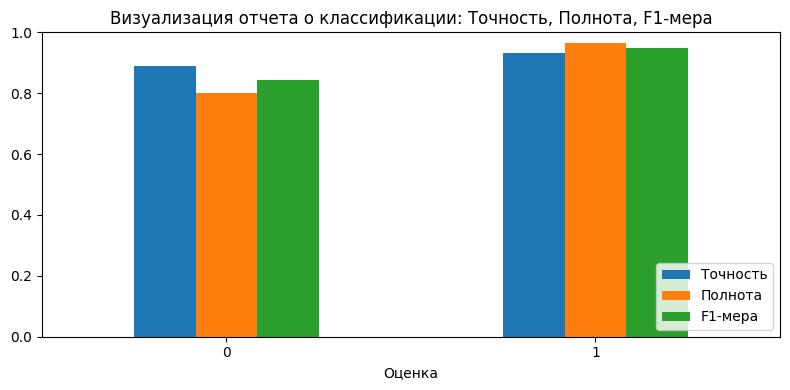

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

df_report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

classes = ['0', '1']
metrics = ['precision', 'recall', 'f1-score']

df_plot = df_report.loc[classes, metrics]
df_plot.columns = ['Точность', 'Полнота', 'F1-мера']
df_plot.plot(kind='bar', figsize=(8, 4))

plt.title('Визуализация отчета о классификации: Точность, Полнота, F1-мера')
plt.xlabel('Оценка')
plt.ylim(0, 1)
plt.xticks(rotation = 0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

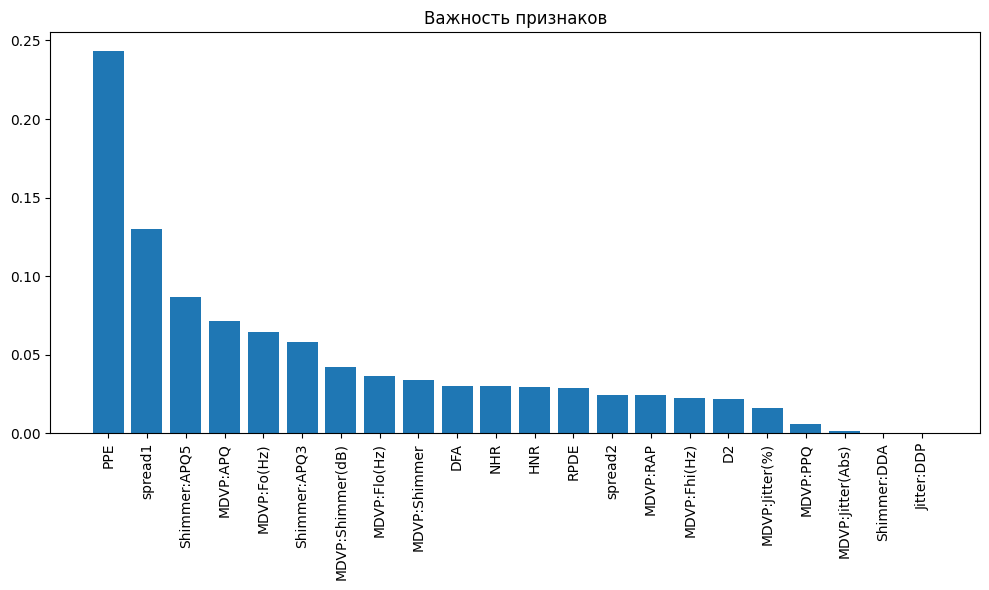

In [ ]:
importances = model.feature_importances_
features = x.columns

indices = importances.argsort()[::-1] #сортирует индексы важности признаков по уменьшению

plt.figure(figsize=(10, 6))
plt.title("Важность признаков")
plt.bar(range(x.shape[1]), importances[indices])
plt.xticks(range(x.shape[1]), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scores = cross_val_score(model, x, y, cv=rkf, scoring='accuracy')

print(f"Повторная кросс-валидация (5×10 = 50 фолдов):")
print(f"Среднее: {scores.mean():.4f} ± {scores.std():.4f}")

Повторная кросс-валидация (5×10 = 50 фолдов):
Среднее: 0.9118 ± 0.0394


Задача 3. Творческая

Задача состоит в разработке модели машинного обучения, которая классифицирует свечевые паттерны.

Данные для обучения, тестирования и прогноза будут синтетическими и сформированы вручную. Для этого выберем 16 основных свечевых паттернов и реализуем функцию, которая будет описывать паттерны. Для реалистичности данных, к ним будут применены шумы.

In [ ]:
import numpy as np

# ==============================
# 1. ПАРАМЕТРЫ ПАТТЕРНОВ
# ==============================

ONE_CANDLE_PATTERNS = {
    "Hammer":              ((0.001, 0.003), (0.0001, 0.0005), (0.05, 0.10),  True),
    "Hanging Man":         ((0.001, 0.003), (0.0001, 0.0005), (0.05, 0.10),  False),
    "Inverted Hammer":     ((0.001, 0.003), (0.05, 0.10),    (0.0001, 0.0005), True),
    "Shooting Star":       ((0.001, 0.003), (0.05, 0.10),    (0.0001, 0.0005), False),
    "Doji":                ((0.00005, 0.0002), (0.01, 0.03), (0.01, 0.03), None),
    "Dragonfly Doji": ((0.00001, 0.00005), (0.0001, 0.0003), (0.06, 0.12), None),
    "Gravestone Doji": ((0.00001, 0.00005), (0.06, 0.12), (0.0001, 0.0003), None),
}

TWO_CANDLE_PATTERNS = {
    "Bullish Engulfing": {"type": "engulfing", "direction": "bullish", "first_candle": "bearish", "engulf_ratio": (1.2, 2.5)},
    "Bearish Engulfing": {"type": "engulfing", "direction": "bearish", "first_candle": "bullish", "engulf_ratio": (1.2, 2.5)},
    "Harami Bullish": {"type": "harami", "direction": "bullish", "first_candle": "bearish", "harami_ratio": (0.3, 0.7)},
    "Harami Bearish": {"type": "harami", "direction": "bearish", "first_candle": "bullish", "harami_ratio": (0.3, 0.7)},
    "Piercing Line": {"type": "piercing", "first_candle": "bearish", "penetration": (0.5, 0.8)},
}

THREE_CANDLE_PATTERNS = {
    "Morning Star": {"type": "star", "direction": "bullish", "first": "bearish", "second": "small", "third": "bullish", "gap_down": (0.005, 0.02), "gap_up": (0.005, 0.02)},
    "Evening Star": {"type": "star", "direction": "bearish", "first": "bullish", "second": "small", "third": "bearish", "gap_up": (0.005, 0.02), "gap_down": (0.005, 0.02)},
    "Three White Soldiers": {"type": "three_advancing", "direction": "bullish", "candle_size_ratio": (0.8, 1.2), "no_upper_shadow": True},
    "Three Black Crows": {"type": "three_advancing", "direction": "bearish", "candle_size_ratio": (0.8, 1.2), "no_lower_shadow": True}
}

PATTERN_NAMES = [
    "Hammer", "Inverted Hammer", "Bullish Engulfing", "Bearish Engulfing",
    "Morning Star", "Evening Star", "Doji", "Dragonfly Doji",
    "Gravestone Doji", "Shooting Star", "Hanging Man", "Three White Soldiers",
    "Three Black Crows", "Harami Bullish", "Harami Bearish", "Piercing Line"
]

NO_PATTERN_LABEL = 16

# ==============================
# 2. ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ==============================

def _make_candle(base, body_size, upper_shadow, lower_shadow, is_bullish):
    if is_bullish:
        close = base
        open_price = close - body_size
    else:
        open_price = base
        close = open_price - body_size
    high = max(open_price, close) + upper_shadow
    low = min(open_price, close) - lower_shadow
    return [open_price, high, low, close]

def generate_single_candle_pattern(pattern_name, base_price=100.0, noise_level=0.01):
    (body_min, body_max), (up_min, up_max), (low_min, low_max), is_bullish = ONE_CANDLE_PATTERNS[pattern_name]
    body_size = np.random.uniform(body_min, body_max) * base_price
    upper_shadow = np.random.uniform(up_min, up_max) * base_price
    lower_shadow = np.random.uniform(low_min, low_max) * base_price

    if is_bullish is True:
        close = base_price
        open_price = close - body_size
    elif is_bullish is False:
        open_price = base_price
        close = open_price - body_size
    else:
        mid = base_price
        open_price = mid - body_size / 2
        close = mid + body_size / 2
        if np.random.rand() > 0.5:
            open_price, close = close, open_price

    high = max(open_price, close) + upper_shadow
    low = min(open_price, close) - lower_shadow
    candle = np.array([open_price, high, low, close], dtype=np.float32)

    noise = np.random.normal(0, noise_level * base_price, size=4)
    candle_noisy = candle + noise
    o, h, l, c = candle_noisy
    final_high = max(h, o, c)
    final_low = min(l, o, c)

    if is_bullish is None:
        avg = (o + c) / 2
        diff = abs(o - c)
        if diff > 0.01 * base_price:
            o = avg - diff * 0.1
            c = avg + diff * 0.1

    return [o, final_high, final_low, c]

def generate_two_candle_pattern(name, base_price=100.0, noise_level=0.01):
    cfg = TWO_CANDLE_PATTERNS[name]
    body1 = np.random.uniform(0.01, 0.03) * base_price
    shadow1 = np.random.uniform(0.002, 0.01) * base_price
    first_bull = (cfg["first_candle"] == "bullish")
    c1 = _make_candle(base_price, body1, shadow1, shadow1, first_bull)
    candles = [c1]

    if cfg["type"] == "engulfing":
        ratio = np.random.uniform(*cfg["engulf_ratio"])
        body2 = body1 * ratio
        shadow2 = shadow1 * np.random.uniform(0.8, 1.2)
        second_bull = (cfg["direction"] == "bullish")
        if second_bull:
            open2 = c1[3] - np.random.uniform(0.6, 1.0) * body2
            close2 = c1[0] + np.random.uniform(0.6, 1.0) * body2
        else:
            open2 = c1[3] + np.random.uniform(0.6, 1.0) * body2
            close2 = c1[0] - np.random.uniform(0.6, 1.0) * body2
        high2 = max(open2, close2) + shadow2
        low2 = min(open2, close2) - shadow2
        c2 = [open2, high2, low2, close2]

    elif cfg["type"] == "harami":
        ratio = np.random.uniform(*cfg["harami_ratio"])
        body2 = body1 * ratio
        shadow2 = shadow1 * 0.5
        second_bull = (cfg["direction"] == "bullish")
        body1_low = min(c1[0], c1[3])
        body1_high = max(c1[0], c1[3])
        if second_bull:
            close2 = np.random.uniform(body1_low + 0.2*body1, body1_high - 0.1*body1)
            open2 = close2 - body2
        else:
            open2 = np.random.uniform(body1_low + 0.2*body1, body1_high - 0.1*body1)
            close2 = open2 - body2
        high2 = max(open2, close2) + shadow2
        low2 = min(open2, close2) - shadow2
        c2 = [open2, high2, low2, close2]

    elif cfg["type"] == "piercing":
        body2 = body1 * np.random.uniform(0.8, 1.2)
        shadow2 = shadow1
        open2 = c1[2] - np.random.uniform(0.001, 0.01) * base_price
        penetration = np.random.uniform(*cfg["penetration"])
        close2 = c1[3] + penetration * (c1[0] - c1[3])
        high2 = max(open2, close2) + shadow2
        low2 = min(open2, close2) - shadow2
        c2 = [open2, high2, low2, close2]

    candles.append(c2)
    arr = np.array(candles)
    noise = np.random.normal(0, noise_level * base_price, arr.shape)
    arr += noise
    result = []
    for o, h, l, c in arr:
        result.append([o, max(h, o, c), min(l, o, c), c])
    return result

def generate_three_candle_pattern(name, base_price=100.0, noise_level=0.01):
    cfg = THREE_CANDLE_PATTERNS[name]
    candles = []
    body_size = np.random.uniform(0.01, 0.025) * base_price
    shadow = np.random.uniform(0.002, 0.01) * base_price

    if cfg["type"] == "star":
        first_bull = (cfg["first"] == "bullish")
        c1 = _make_candle(base_price, body_size, shadow, shadow, first_bull)
        candles.append(c1)

        gap1 = np.random.uniform(*cfg["gap_down" if cfg["direction"]=="bullish" else "gap_up"])
        base2 = c1[3] - gap1 * base_price if cfg["direction"]=="bullish" else c1[3] + gap1 * base_price
        small_body = np.random.uniform(0.001, 0.005) * base_price
        small_shadow = np.random.uniform(0.001, 0.008) * base_price
        c2 = _make_candle(base2, small_body, small_shadow, small_shadow, is_bullish=None)
        candles.append(c2)

        gap2 = np.random.uniform(*cfg["gap_up" if cfg["direction"]=="bullish" else "gap_down"])
        base3 = c2[3] + gap2 * base_price if cfg["direction"]=="bullish" else c2[3] - gap2 * base_price
        c3 = _make_candle(base3, body_size * np.random.uniform(0.9,1.3), shadow, shadow, cfg["direction"]=="bullish")
        candles.append(c3)

    elif cfg["type"] == "three_advancing":
        price = base_price
        for _ in range(3):
            body = body_size * np.random.uniform(*cfg["candle_size_ratio"])
            up_sh = 0.001 * base_price if cfg.get("no_upper_shadow") else shadow
            lo_sh = 0.001 * base_price if cfg.get("no_lower_shadow") else shadow
            c = _make_candle(price, body, up_sh, lo_sh, cfg["direction"]=="bullish")
            candles.append(c)
            price = c[3]

    arr = np.array(candles)
    noise = np.random.normal(0, noise_level * base_price, arr.shape)
    arr += noise
    result = []
    for o, h, l, c in arr:
        result.append([o, max(h, o, c), min(l, o, c), c])
    return result

def generate_background_candles(n, start_price=100.0, volatility=0.01):
    candles = []
    price = start_price
    for _ in range(n):
        change = np.random.normal(0, volatility) * price
        new_price = price + change
        body = abs(np.random.normal(0, volatility/2) * new_price)
        if np.random.rand() > 0.5:
            o = new_price - body
            c = new_price
        else:
            o = new_price + body
            c = new_price
        h = max(o, c) + np.random.exponential(volatility/3) * price
        l = min(o, c) - np.random.exponential(volatility/3) * price
        candles.append([o, h, l, c])
        price = c
    return candles

# ==============================
# 3. ГЕНЕРАЦИЯ ОКНА И ДАТАСЕТА
# ==============================

def generate_window_with_pattern(pattern_name, base_price=100.0, noise_level=0.01):
    if pattern_name in ONE_CANDLE_PATTERNS:
        pattern_candles = [generate_single_candle_pattern(pattern_name, base_price, noise_level)]
        n_pat = 1
        pos = 0
    elif pattern_name in TWO_CANDLE_PATTERNS:
        pattern_candles = generate_two_candle_pattern(pattern_name, base_price, noise_level)
        n_pat = 2
        pos = 0
    elif pattern_name in THREE_CANDLE_PATTERNS:
        pattern_candles = generate_three_candle_pattern(pattern_name, base_price, noise_level)
        n_pat = 3
        pos = 0

    window = [None] * 5
    for i in range(n_pat):
        window[i] = pattern_candles[i]

    right_count = 5 - n_pat
    if right_count > 0:
        last_price = window[n_pat - 1][3]
        right_bg = generate_background_candles(right_count, start_price=last_price, volatility=0.008)
        for i in range(right_count):
            window[n_pat + i] = right_bg[i]

    for i in range(5):
        if window[i] is None:
            window[i] = [base_price, base_price + 0.1, base_price - 0.1, base_price]
    return np.array(window, dtype=np.float32)

def generate_dataset(
    n_samples_per_pattern=2000,
    include_no_pattern=True,
    n_no_pattern=2000,
    base_price_range=(50.0, 200.0),
    noise_level=0.0015,
    normalize=True
):
    X = []
    y = []

    hard_patterns = {
      "Doji", "Dragonfly Doji", "Gravestone Doji",
      "Hammer", "Inverted Hammer", "Shooting Star", "Hanging Man"
    }

    for label, name in enumerate(PATTERN_NAMES):
        if name in hard_patterns:
            n_samples = 5000
        else:
            n_samples = n_samples_per_pattern

        for _ in range(n_samples):
            base = np.random.uniform(*base_price_range)
            window = generate_window_with_pattern(name, base_price=base, noise_level=noise_level)
            if normalize:
                ref = window[0, 3]
                window = (window - ref) / ref
            X.append(window)
            y.append(label)

    if include_no_pattern:
        for _ in range(n_no_pattern):
            base = np.random.uniform(*base_price_range)
            window = generate_background_candles(5, start_price=base, volatility=0.01)
            window = np.array(window, dtype=np.float32)
            if normalize:
                ref = window[0, 3]
                window = (window - ref) / ref
            X.append(window)
            y.append(NO_PATTERN_LABEL)

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

# ==============================
# 5. ИНЖЕНЕРИЯ ПРИЗНАКОВ
# ==============================

def extract_candle_features(candle):
    o, h, l, c = candle
    body = c - o
    body_abs = abs(body)
    candle_range = h - l + 1e-8

    upper_shadow = h - max(o, c)
    lower_shadow = min(o, c) - l

    body_ratio = body_abs / candle_range
    is_doji_like = 1.0 if body_ratio < 0.05 else 0.0
    upper_ratio = upper_shadow / candle_range
    lower_ratio = lower_shadow / candle_range

    is_bullish = 1.0 if c > o else 0.0

    shadow_ratio = (upper_shadow + 1e-8) / (lower_shadow + 1e-8)
    if candle_range > 0:
        close_position = (c - l) / candle_range
        open_position = (o - l) / candle_range
    else:
        close_position = open_position = 0.5

    return [
        body, body_abs, candle_range,
        upper_shadow, lower_shadow,
        body_ratio, upper_ratio, lower_ratio,
        is_bullish,
        shadow_ratio,
        close_position,
        open_position,
        is_doji_like
    ]

def extract_window_features(window):
    features = []
    for i in range(5):
        features.extend(extract_candle_features(window[i]))

    for i in range(4):
        gap = window[i+1][0] - window[i][3]
        features.append(gap)

    return np.array(features, dtype=np.float32)

# ==============================
# 6. ОБУЧЕНИЕ МОДЕЛИ
# ==============================

if __name__ == "__main__":
    X, y = generate_dataset(
        n_samples_per_pattern=2000,
        include_no_pattern=True,
        n_no_pattern=1000,
        noise_level=0.0002,
        normalize=True
    )

    print("Извлечение признаков...")
    X_features = np.array([extract_window_features(x) for x in X])
    print(f"Форма признаков: {X_features.shape}")

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y, test_size=0.2, random_state=42, stratify=y
    )

    from xgboost import XGBClassifier
    from sklearn.metrics import classification_report

    print("Обучение модели...")
    model = XGBClassifier(
        n_estimators=700,
        learning_rate=0.01,
        max_depth=16,
        random_state=42,
        objective='multi:softmax',
        num_class=17,
        eval_metric='mlogloss',
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1,
        reg_lambda=1
    )

    from sklearn.utils.class_weight import compute_sample_weight

    sample_weights = compute_sample_weight('balanced', y_train)
    model.fit(X_train, y_train, sample_weight=sample_weights)

    y_pred = model.predict(X_test)
    print("\nОтчёт по классификации:")
    print(classification_report(y_test, y_pred, target_names=PATTERN_NAMES + ["No Pattern"]))



Извлечение признаков...
Форма признаков: (54000, 69)
Обучение модели...

Отчёт по классификации:
                      precision    recall  f1-score   support

              Hammer       1.00      1.00      1.00      1000
     Inverted Hammer       1.00      1.00      1.00      1000
   Bullish Engulfing       1.00      1.00      1.00       400
   Bearish Engulfing       1.00      1.00      1.00       400
        Morning Star       1.00      1.00      1.00       400
        Evening Star       1.00      1.00      1.00       400
                Doji       1.00      1.00      1.00      1000
      Dragonfly Doji       0.99      0.99      0.99      1000
     Gravestone Doji       1.00      0.99      1.00      1000
       Shooting Star       1.00      1.00      1.00      1000
         Hanging Man       1.00      0.99      1.00      1000
Three White Soldiers       1.00      1.00      1.00       400
   Three Black Crows       1.00      1.00      1.00       400
      Harami Bullish       1.00   

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from matplotlib import pyplot as plt

Accuracy: 0.9958333333333333


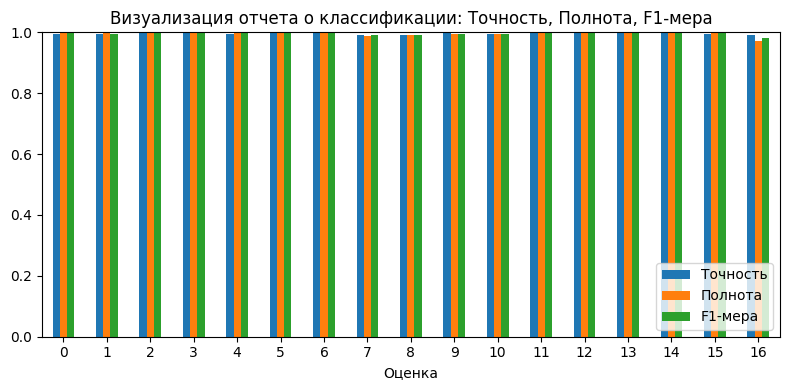

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

df_report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

classes = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16']
metrics = ['precision', 'recall', 'f1-score']

df_plot = df_report.loc[classes, metrics]
df_plot.columns = ['Точность', 'Полнота', 'F1-мера']
df_plot.plot(kind='bar', figsize=(8, 4))

plt.title('Визуализация отчета о классификации: Точность, Полнота, F1-мера')
plt.xlabel('Оценка')
plt.ylim(0, 1)
plt.xticks(rotation = 0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()